In [1]:
# 读取下数据集，然后打印出来
data_file_path = "./lcsts_tsv/data1.tsv"
with open(data_file_path, "rt", encoding="utf-8") as f: 
    for idx, line in enumerate(f):
        if idx >= 2:
            break
        line.strip()
        print(line)
        


修改后的立法法全文公布!=!新华社受权于18日全文播发修改后的《中华人民共和国立法法》，修改后的立法法分为“总则”“法律”“行政法规”“地方性法规、自治条例和单行条例、规章”“适用与备案审查”“附则”等6章，共计105条。

深圳机场9死24伤续：司机全责赔偿或超千万!=!一辆小轿车，一名女司机，竟造成9死24伤。日前，深圳市交警局对事故进行通报：从目前证据看，事故系司机超速行驶且操作不当导致。目前24名伤员已有6名治愈出院，其余正接受治疗，预计事故赔偿费或超一千万元。



观察下数据集的构成，发现中间是用!=!隔开的

# 创建Dataset

In [ ]:
import torch
from torch.utils.data import Dataset

class LCSTS(Dataset):
    def __init__(self, data_file_path):
        self.max_dataset_size = 2000
        self.data = self.load_data(data_file_path)
        
        
    def load_data(self, data_file_path):
        data = {}
        with open(data_file_path, "rt", encoding="utf-8") as f: 
            for idx, line in enumerate(f):
                if idx >= self.max_dataset_size:
                    break
                items = line.strip().split("!=!")
                data[idx] = {
                    "title":items[0],
                    "content":items[1]
                }
        return data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

In [3]:
train_data = LCSTS('./lcsts_tsv/data1.tsv')
valid_data = LCSTS('./lcsts_tsv/data2.tsv')
test_data = LCSTS('./lcsts_tsv/data3.tsv')

# 数据预处理

mT5 tokenizer 对文本进行分词

In [4]:
from transformers import AutoTokenizer

model_checkpoint = "csebuetnlp/mT5_multilingual_XLSum"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=False)

e:\anaconda3\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [5]:
inputs = tokenizer("我叫张三，在苏州大学学习计算机。")
print(inputs)
print(tokenizer.convert_ids_to_tokens(inputs.input_ids))

{'input_ids': [259, 3003, 27333, 8922, 2092, 261, 1083, 117707, 9792, 24920, 123553, 306, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
['▁', '我', '叫', '张', '三', ',', '在', '苏州', '大学', '学习', '计算机', '。', '</s>']


# 创建DataLoader

In [6]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSeq2SeqLM

In [7]:
max_input_length = 512
max_target_length = 64

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device : {device}")

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
model = model.to(device)

def collate_fn(batch_samples):
    batch_inputs, batch_targets = [], []
    for sample in batch_samples:
        batch_inputs.append(sample["content"])
        batch_targets.append(sample["title"])
    
    # 内容指定text来表示这个是输入的语言，然后进行tokenizer, 一般来讲输入和输出的语言可能不同， 因此需要特别指定
    batch_data = tokenizer(
        text = batch_inputs,
        padding=True,
        max_length = max_input_length,
        truncation = True,
        return_tensors = "pt"
    )
    
    # 标签用text_target来表示输出的语言，然后进行tokenizer
    labels = tokenizer(
        text_target = batch_targets,
        padding=True,
        max_length = max_target_length,
        truncation= True,
        return_tensors = "pt"
    )["input_ids"]
    
    # 自动生成解码器输入 (Teacher Forcing 所需的向右平移一格)
    batch_data["decoder_input_ids"] = model.prepare_decoder_input_ids_from_labels(labels)
    
    # 4. 把结束符 <EOS> 后面的填充部分换成 -100， 因为在nn.CrossEntropyLoss当中ignore为-100， 即他会自动忽略这个值，这里是让PAD不参与预算
    row_indices, col_indices = torch.where(labels == tokenizer.eos_token_id)
    for row_idx, col_idx in zip(row_indices, col_indices):
        labels[row_idx][col_idx+1:] = -100
        
    batch_data["labels"] = labels
    
    return batch_data
    
    

device : cuda


In [8]:
train_dataloader = DataLoader(train_data, batch_size=4, shuffle=True, collate_fn=collate_fn)
valid_dataloader = DataLoader(valid_data, batch_size=4, shuffle=False, collate_fn=collate_fn)


In [9]:
batch = next(iter(train_dataloader))
for k, v in batch.items(): 
    print(k, v.shape)


input_ids torch.Size([4, 72])
attention_mask torch.Size([4, 72])
decoder_input_ids torch.Size([4, 19])
labels torch.Size([4, 19])


# 创建train_loop函数

In [10]:
from tqdm.auto import tqdm

def train_loop(dataloader, model, optimizer, lr_shceduler, epoch, total_loss, finish_batch_num = 0):
    progress_bar = tqdm(dataloader)
    model.train()
    
    for batch_data in progress_bar:
        batch_data.to_(device)
        outputs = model(**batch_data)
        optimizer.zero_grad()
        outputs.loss.backward()
        optimizer.step()
        lr_shceduler.step()
        total_loss += outputs.loss.item()
        finish_batch_num += 1
        progress_bar.set_description(f"loss : {total_loss / finish_batch_num:>7f}")
    return total_loss, finish_batch_num

# 了解Rouge库来评估摘要的好坏

对于评估概括的好坏， 通过Recall 和 Precision这两个指标进行评估

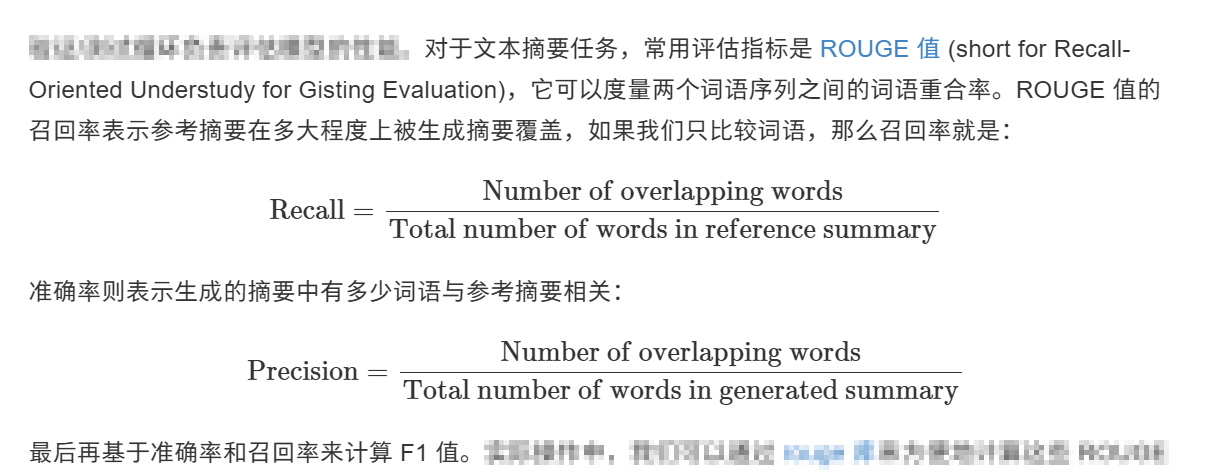

In [11]:
from rouge import Rouge

generated_summary = "I absolutely loved reading the Hunger Games"
referene_summary = "I loved reading the Hunger Games"

rouge = Rouge()

scores = rouge.get_scores(
    hyps=[generated_summary],
    refs=[referene_summary]
)

print(scores)

[{'rouge-1': {'r': 1.0, 'p': 0.8571428571428571, 'f': 0.9230769181065088}, 'rouge-2': {'r': 0.8, 'p': 0.6666666666666666, 'f': 0.7272727223140496}, 'rouge-l': {'r': 1.0, 'p': 0.8571428571428571, 'f': 0.9230769181065088}}]


会看到上述有三种指标 ：

rouge-1：基于单个词（Unigram）的匹配 ， 它只看单个词是否重合，不看词的顺序。

rouge-2：基于相邻两个词（Bigram）的匹配它衡量文本的流畅度，看相邻的两个词是否也能匹配上。

rouge-l：基于最长公共子序列（Longest Common Subsequence）

rouge 库默认使用空格进行分词，因此无法处理中文、日文等语言，最简单的办法是按字进行切分，当然也可以使用分词器分词后再进行计算，否则会计算出不正确的 ROUGE 值：

In [12]:
from rouge import Rouge

generated_summary = "我在苏州大学学习计算机，苏州大学很美丽。"
reference_summary = "我在环境优美的苏州大学学习计算机。"

rouge = Rouge()

TOKENIZE_CHINESE = lambda x: ' '.join(x)

# from transformers import AutoTokenizer
# model_checkpoint = "csebuetnlp/mT5_multilingual_XLSum"
# tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# TOKENIZE_CHINESE = lambda x: ' '.join(
#     tokenizer.convert_ids_to_tokens(tokenizer(x).input_ids, skip_special_tokens=True)
# )

scores = rouge.get_scores(
    hyps=[TOKENIZE_CHINESE(generated_summary)], 
    refs=[TOKENIZE_CHINESE(reference_summary)]
)[0]


# 这里直接使用没有空格的句子， 会出现无法分析的情况
print('ROUGE:', scores)
scores = rouge.get_scores(
    hyps=[generated_summary], 
    refs=[reference_summary]
)[0]
print('wrong ROUGE:', scores)

ROUGE: {'rouge-1': {'r': 0.75, 'p': 0.8, 'f': 0.7741935433922998}, 'rouge-2': {'r': 0.5625, 'p': 0.5625, 'f': 0.562499995}, 'rouge-l': {'r': 0.6875, 'p': 0.7333333333333333, 'f': 0.7096774143600416}}
wrong ROUGE: {'rouge-1': {'r': 0.0, 'p': 0.0, 'f': 0.0}, 'rouge-2': {'r': 0.0, 'p': 0.0, 'f': 0.0}, 'rouge-l': {'r': 0.0, 'p': 0.0, 'f': 0.0}}


# 了解  AutoModelForSeq2SeqLM 的预测生成函数

In [13]:
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

model_checkpoint = "csebuetnlp/mT5_multilingual_XLSum"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
model.to(device)

article_text = """受众在哪里，媒体就应该在哪里，媒体的体制、内容、技术就应该向哪里转变。媒体融合关键是以人为本，即满足大众的信息需求，为受众提供更优质的服务。这就要求媒体在融合发展的过程中，既注重技术创新，又注重用户体验。"""
input_ids = tokenizer(
    article_text,
    return_tensors = "pt",
    truncation=True,
    max_length=512
).to(device)


generated_tokens = model.generate(
    input_ids["input_ids"],
    attention_mask=input_ids["attention_mask"],
    max_length=32,
    no_repeat_ngram_size=2, # 指定了连续的两个词语不能出现两次
    num_beams=4 # num_beams 每次推理都保留可能的4个词语， 分别从4个词进行推理
)

summary = tokenizer.decode(
    generated_tokens[0],
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

summary

Using cuda device


e:\anaconda3\envs\pytorch\lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


'受众在哪里,媒体融合为何?'

# 创建test_loop函数

In [14]:
import numpy as np
from rouge import Rouge

rouge = Rouge()

def test_loop(dataloader, model):
    preds, labels = [], []
    
    model.eval()
    
    for batch_data in tqdm(dataloader):
        batch_data = batch_data.to(device)
        with torch.inference_mode():
            generated_summary = model.generate(
                batch_data["input_ids"],
                attention_mask = batch_data["attention_mask"],
                max_length = max_target_length,
                num_beams = 4,
                no_repeat_ngram_size=2
            ).cpu().numpy()
            
        label_tokens = batch_data["labels"].cpu().numpy()
        
        decoded_preds = tokenizer.batch_decode(generated_summary, skip_special_tokens=True)
        
        # 前面为了不然交叉熵计算Pad的概率， 因此需要把pad token id 改成 -100, np.where(条件, 条件为真时的值, 条件为假时的值)
        label_tokens = np.where(label_tokens != -100, label_tokens, tokenizer.pad_token_id)  
        decoded_labels = tokenizer.batch_decode(label_tokens, skip_special_tokens=True)
        
        # 这里pred 和 label 都是一句话，预测的话，然后把这句话的每个字之间都加入空格，迎合后的Rouge计算
        preds += [' '.join(pred.strip()) for pred in decoded_preds]
        labels += [' '.join(label.strip()) for label in decoded_labels]
    
    scores = rouge.get_scores(hyps=preds, refs=labels, avg=True) # 这里会把整个batch的三个数据都算出来，返回一个字典
    result = {key: value['f'] * 100 for key, value in scores.items()}
    result['avg'] = np.mean(list(result.values()))
    print(f"Rouge1: {result['rouge-1']:>0.2f} Rouge2: {result['rouge-2']:>0.2f} RougeL: {result['rouge-l']:>0.2f}\n")
    return result 

# 先看下没训练的模型的精度

In [ ]:
test_data = LCSTS('lcsts_tsv/data3.tsv')
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_fn)
print(f"device : {device}")
test_loop(test_dataloader, model)

device : cuda


  0%|          | 6/6250 [01:33<22:17:52, 12.86s/it]

# 开始训练

In [ ]:
from transformers import get_scheduler
from torch.optim import AdamW 

learning_rate = 2e-5
epoch_num = 10

optimizer = AdamW(model.parameters(), lr = learning_rate)
lr_scheduler = get_scheduler(
    "linear",
    optimizer = optimizer,
    num_warmup_steps=0,
    num_training_steps=epoch_num*len(train_dataloader)
)

total_loss = 0
best_avg_rouge = 0
finish_batch_num = 0

for t in range(epoch_num):
    print(f"Epoch {t+1}/{epoch_num}\n-------------------------------")
    total_loss,finish_batch_num = train_loop(train_dataloader, model, optimizer, lr_scheduler, t+1, total_loss)
    valid_rouge = test_loop(valid_dataloader, model)
    rouge_avg = valid_rouge['avg']
    if rouge_avg > best_avg_rouge:
        best_avg_rouge = rouge_avg
        print('saving new weights...\n')
        torch.save(model.state_dict(), f'epoch_{t+1}_valid_rouge_{rouge_avg:0.4f}_model_weights.bin')
print("Done!")    